In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import random
from zonolayer import compute_zonolayer_bounds
from sklearn.model_selection import train_test_split

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Heating Load - Energy Dataset

In [2]:
df = pd.read_csv('Data/energy_efficiency_data.csv')
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])
y_heating = df['Heating_Load'].values

def intervalise_heating_load(y):
    n = len(y)
    r = np.abs(np.random.normal(loc=0.5, scale=0.25, size=n))
    b = np.random.uniform(low=-1.0, high=1.0, size=n)
    m = y - r + (1 + b) * r
    return pd.DataFrame({"y": y, "y_lower": m - r, "y_upper": m + r})

intervals = intervalise_heating_load(y_heating)

# Split and Normalize
X_train, X_test, y_low_tr, y_low_te, y_up_tr, y_up_te = train_test_split(
    X.values, intervals['y_lower'].values, intervals['y_upper'].values, test_size=0.25, random_state=42
)

X_min, X_max = X_train.min(axis=0), X_train.max(axis=0)
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)
y_mid_tr, y_rad_tr = (y_low_tr + y_up_tr) / 2, (y_up_tr - y_low_tr) / 2
y_mean, y_std = y_mid_tr.mean(), y_mid_tr.std()

# Normalise both bounds
y_low_tr = (y_low_tr - y_mean) / y_std
y_up_tr  = (y_up_tr  - y_mean) / y_std

class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=8, zono_dim=8):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )
        self.regressor = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        if return_features:
            return out, features
        return out


def train_centre(x_t, y_lb_t, y_ub_t, epochs=7000, lr=0.01, print_every=50):
    y_mid = ((y_lb_t + y_ub_t) / 2).reshape(-1, 1)
    
    centre_net = RegressionNetwork(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        pred = centre_net(x_t) 
        loss = criterion(pred, y_mid)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")
    return centre_net

def extract_latent_features(model, x):
    model.eval()
    with torch.no_grad():
        preds, features = model(x, return_features=True)
    return preds.cpu().numpy(), features.cpu().numpy()

x_t = torch.tensor(X_train, dtype=torch.float32)
y_lb_t = torch.tensor(y_low_tr, dtype=torch.float32)
y_ub_t = torch.tensor(y_up_tr, dtype=torch.float32)

# Zonolayer computation
centre_net = train_centre(x_t, y_lb_t, y_ub_t)
pred_train, latent_train = extract_latent_features(centre_net, x_t)
pred_test, latent_test = extract_latent_features(centre_net, torch.tensor(X_test, dtype=torch.float32))
zonolayer = compute_zonolayer_bounds(latent_train, y_low_tr, y_up_tr, latent_test)


Epoch 50: MSE = 0.113336
Epoch 100: MSE = 0.082019
Epoch 150: MSE = 0.075378
Epoch 200: MSE = 0.073058
Epoch 250: MSE = 0.069835
Epoch 300: MSE = 0.065498
Epoch 350: MSE = 0.061647
Epoch 400: MSE = 0.053725
Epoch 450: MSE = 0.042184
Epoch 500: MSE = 0.034479
Epoch 550: MSE = 0.029677
Epoch 600: MSE = 0.011256
Epoch 650: MSE = 0.009225
Epoch 700: MSE = 0.008797
Epoch 750: MSE = 0.008556
Epoch 800: MSE = 0.008336
Epoch 850: MSE = 0.008127
Epoch 900: MSE = 0.013715
Epoch 950: MSE = 0.007802
Epoch 1000: MSE = 0.007608
Epoch 1050: MSE = 0.007392
Epoch 1100: MSE = 0.007148
Epoch 1150: MSE = 0.011701
Epoch 1200: MSE = 0.006750
Epoch 1250: MSE = 0.006478
Epoch 1300: MSE = 0.006187
Epoch 1350: MSE = 0.005886
Epoch 1400: MSE = 0.006215
Epoch 1450: MSE = 0.005555
Epoch 1500: MSE = 0.005321
Epoch 1550: MSE = 0.005118
Epoch 1600: MSE = 0.004935
Epoch 1650: MSE = 0.004772
Epoch 1700: MSE = 0.004886
Epoch 1750: MSE = 0.004753
Epoch 1800: MSE = 0.004507
Epoch 1850: MSE = 0.004400
Epoch 1900: MSE = 0.0

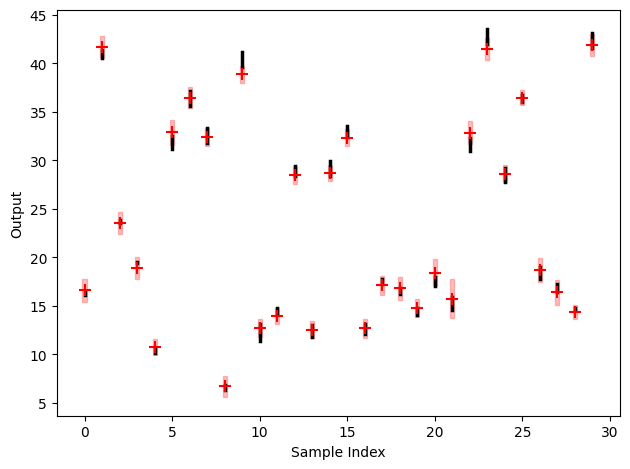

In [3]:
# Denormalise for plotting
yl_zl = zonolayer["y_lower"] * y_std + y_mean
yu_zl = zonolayer["y_upper"] * y_std + y_mean
midpoint_model = zonolayer["midpoint"] * y_std + y_mean

n_plot = 30
idx = np.sort(np.random.choice(len(X_test), n_plot, replace=False))

plt.figure()

width = 0.12  # Width of each interval bar

for i, val in enumerate(idx):

    # True interval
    plt.plot(
        [i, i],
        [y_low_te[val], y_up_te[val]],
        color='black',
        lw=2.5,
        zorder=3,
        label='True Interval' if i == 0 else ""
    )

    # ZonoLayer interval
    plt.fill_between(
        [i - width, i + width],
        yl_zl[val],
        yu_zl[val],
        color='red',
        alpha=0.25,
        label='ZonoLayer Interval' if i == 0 else ""
    )

plt.scatter(
    [i for i in range(n_plot)], 
    midpoint_model[idx], 
    marker='+', color='red', zorder=5, s=80, label='ZonoLayer Midpoint'
)

plt.xlabel("Sample Index")
plt.ylabel("Output")
# plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("HeatingLoad.pdf", bbox_inches="tight")
plt.show()